In [1]:
#Importing required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer

from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, auc
)

#Setting random state for reproducibility and seaborn style for better aesthetics
RANDOM_STATE = 8120493
sns.set_style("whitegrid")


In [2]:
#Defining some helper functions for plotting and evaluation
def plot_missingness(df, title_prefix=""):
    miss_pct = df.isnull().mean().sort_values(ascending=False) * 100

    plt.figure(figsize=(8, 0.25 * len(miss_pct) + 2))
    miss_pct[miss_pct > 0].sort_values().plot(kind="barh", color="salmon")
    plt.axvline(20, color="red", linestyle="--", label="20% threshold")
    plt.title(f"{title_prefix} Missing Values (%) by Feature")
    plt.xlabel("% missing")
    plt.legend()
    plt.tight_layout()
    plt.show()

    sample = df.sample(n=min(2000, len(df)), random_state=RANDOM_STATE)
    plt.figure(figsize=(14, 6))
    sns.heatmap(sample.isnull(), cbar=False)
    plt.title(f"{title_prefix} Missingness Heatmap (sampled rows)")
    plt.xlabel("Features")
    plt.ylabel("Sampled rows")
    plt.tight_layout()
    plt.show()

    return miss_pct


def plot_roc_pr(y_true, y_proba, title_prefix="Model"):
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    prec, rec, _ = precision_recall_curve(y_true, y_proba)
    auc_roc = roc_auc_score(y_true, y_proba)
    auc_pr = average_precision_score(y_true, y_proba)

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    ax[0].plot(fpr, tpr, lw=2, label=f"AUC={auc_roc:.3f}")
    ax[0].plot([0, 1], [0, 1], ls="--", c="gray")
    ax[0].set_title(f"{title_prefix} - ROC")
    ax[0].set_xlabel("False Positive Rate")
    ax[0].set_ylabel("True Positive Rate")
    ax[0].legend()
    ax[0].grid(alpha=0.3)

    ax[1].plot(rec, prec, lw=2, label=f"AP={auc_pr:.3f}")
    ax[1].set_title(f"{title_prefix} - Precision-Recall")
    ax[1].set_xlabel("Recall")
    ax[1].set_ylabel("Precision")
    ax[1].legend()
    ax[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_confusion(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm)
    fig, ax = plt.subplots(figsize=(4.5, 4.5))
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def _get_proba_or_score(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    scores = model.decision_function(X)
    return (scores - scores.min()) / (scores.max() - scores.min() + 1e-12)


def fit_and_evaluate(model, X_train, y_train, X_eval, y_eval, name="Model", eval_name="VALID"):
    """Fit on (X_train,y_train), evaluate on (X_eval,y_eval)."""
    model.fit(X_train, y_train)

    proba_eval = _get_proba_or_score(model, X_eval)
    pred_eval = model.predict(X_eval)

    out = {
        "Model": name,
        f"{eval_name}_ROC_AUC": roc_auc_score(y_eval, proba_eval),
        f"{eval_name}_PR_AUC": average_precision_score(y_eval, proba_eval)
    }

    print("=" * 70)
    print(f"{name}  (evaluated on {eval_name})")
    print("=" * 70)
    print(out)
    print(f"\nClassification report ({eval_name}):")
    print(classification_report(y_eval, pred_eval, digits=4))

    plot_roc_pr(y_eval, proba_eval, title_prefix=f"{name} ({eval_name})")
    plot_confusion(y_eval, pred_eval, title=f"{name} - Confusion Matrix ({eval_name})")

    return out, model



In [3]:
#Loading the dataset and performing initial exploration
df = pd.read_csv("Assignment1_mimic dataset.csv")

print("Dataset contains:", df.shape[0], "rows,", df.shape[1], "columns")
print("Target class proportions:\n", df["icu_death_flag"].value_counts(normalize=True))

Dataset contains: 65366 rows, 140 columns
Target class proportions:
 icu_death_flag
0    0.913242
1    0.086758
Name: proportion, dtype: float64


In [4]:
#Defining target variable 
y = df["icu_death_flag"].astype(int)

X = df.drop(columns=["icu_death_flag"])

#Drop identifiers, time columns and direct/near-direct leakage
cols_drop = [
    "subject_id", "hadm_id", "stay_id",
    "intime", "outtime",
    "last_careunit",  
    "deathtime",
    "hospital_expire_flag",
    "los","language"             
]
cols_drop = [c for c in cols_drop if c in X.columns]
X = X.drop(columns=cols_drop)

print("After leakage/id drop:", X.shape)


After leakage/id drop: (65366, 129)


In [5]:

# First split out TEST set 
X_temp_raw, X_test_raw, y_temp, y_test = train_test_split(
    X, y, test_size=0.10, stratify=y, shuffle=True, random_state=RANDOM_STATE
)

# Split remaining into TRAIN and VALIDATION
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_temp_raw, y_temp, test_size=0.111, stratify=y_temp, shuffle=True, random_state=RANDOM_STATE
)

print("Train shape:", X_train_raw.shape)
print("Val   shape:", X_val_raw.shape)
print("Test  shape:", X_test_raw.shape)


Train shape: (52298, 129)
Val   shape: (6531, 129)
Test  shape: (6537, 129)


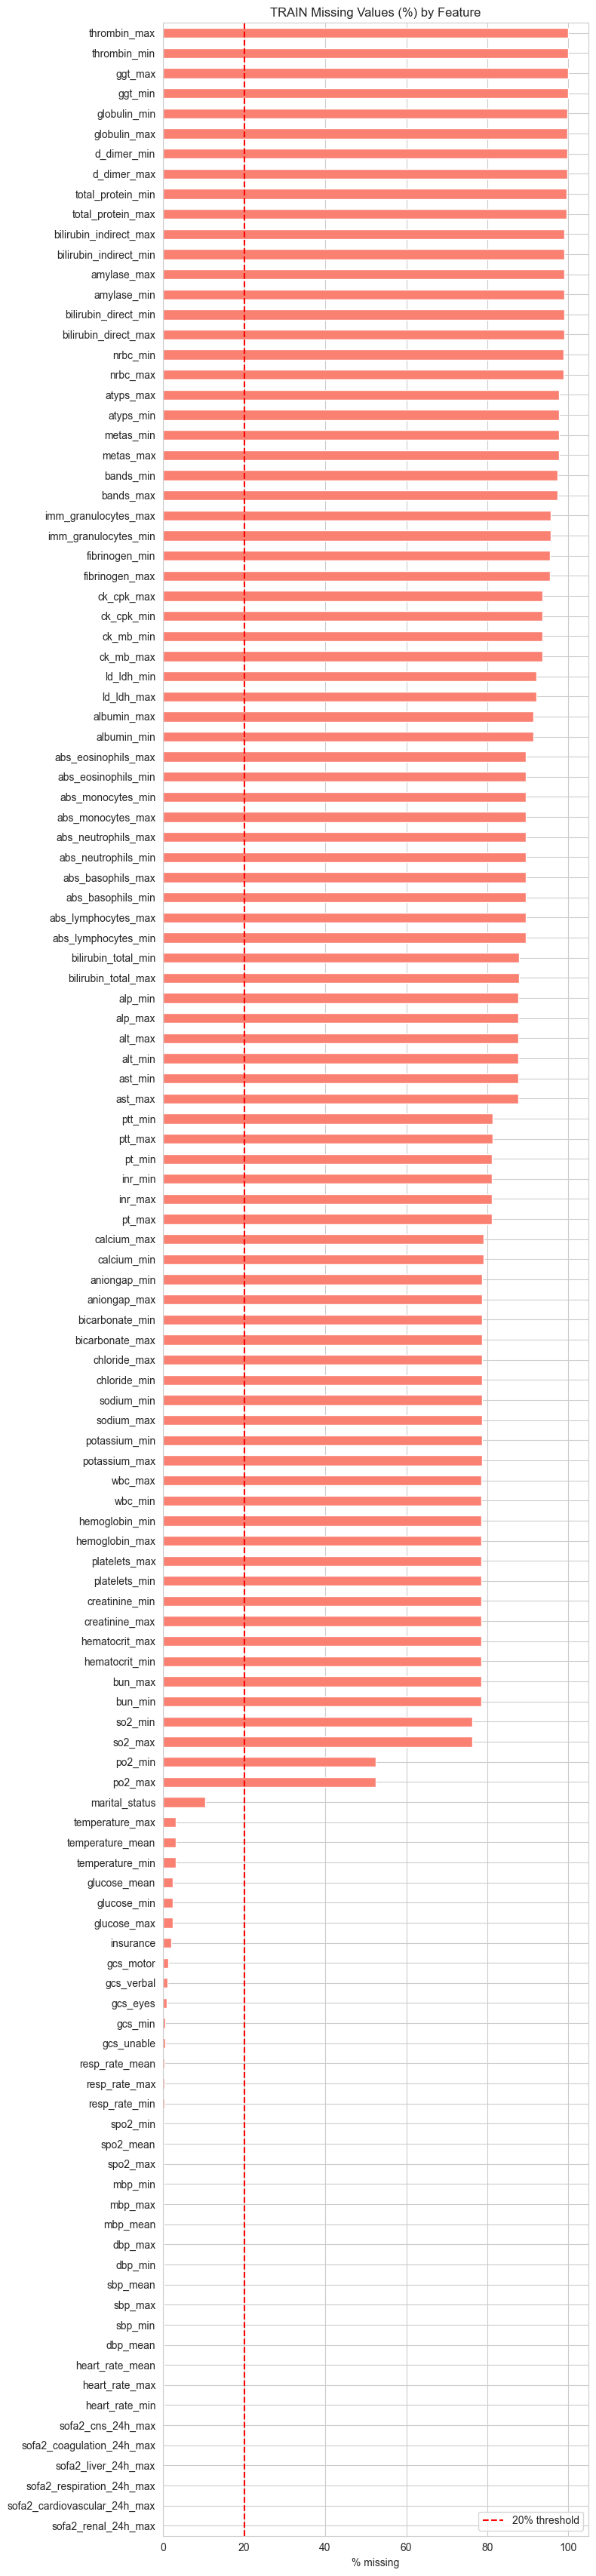

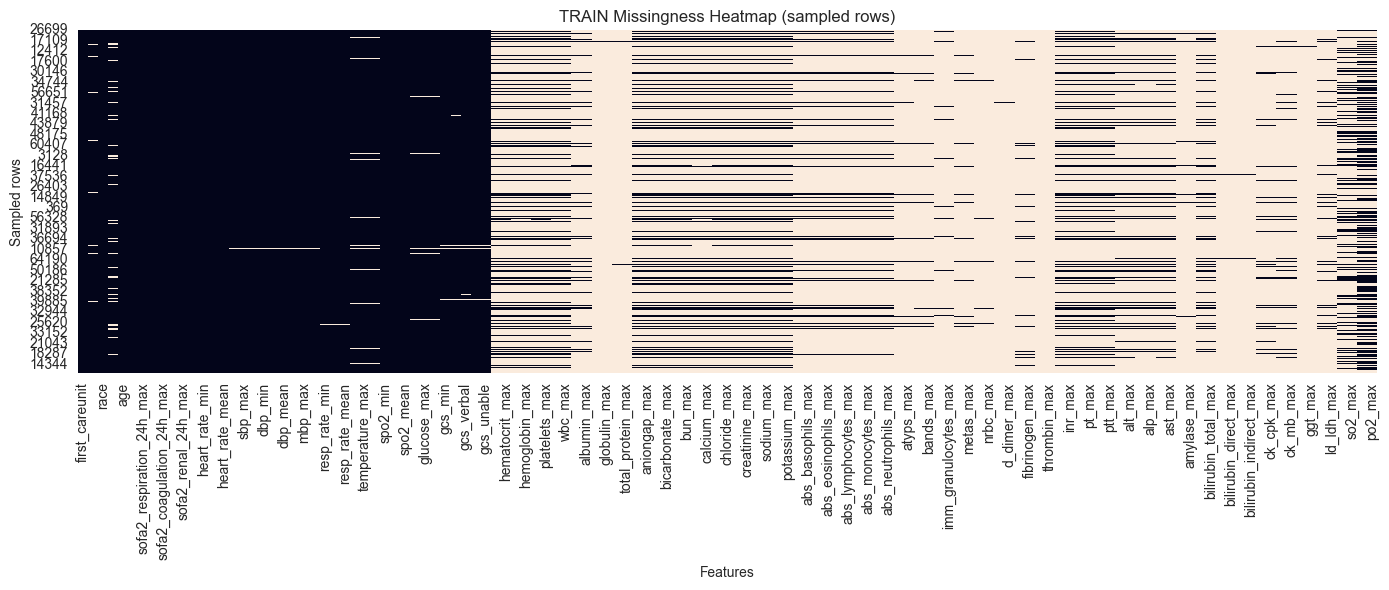

Features dropped for >20% missing (train-based): 88
After missingness drop: (52298, 41) (6531, 41) (6537, 41)


In [6]:
#Analyze missingness in TRAIN set to decide on feature drops
miss_pct_train = plot_missingness(X_train_raw, title_prefix="TRAIN")

#Drop features with >20% missing 
missing_thresh = 20
cols_drop_missing = miss_pct_train[miss_pct_train > missing_thresh].index.tolist()

print(f"Features dropped for >{missing_thresh}% missing (train-based):", len(cols_drop_missing))
X_train_raw = X_train_raw.drop(columns=cols_drop_missing)
X_val_raw   = X_val_raw.drop(columns=cols_drop_missing)
X_test_raw  = X_test_raw.drop(columns=cols_drop_missing)

print("After missingness drop:", X_train_raw.shape, X_val_raw.shape, X_test_raw.shape)


In [7]:
#Categorical cleanup + grouping (fit grouping on TRAIN only)

race_grp_map = {
    'WHITE': 'White',
    'WHITE - OTHER EUROPEAN': 'White',
    'WHITE - EASTERN EUROPEAN': 'White',
    'WHITE - RUSSIAN': 'White',
    'WHITE - BRAZILIAN': 'White',
    'PORTUGUESE': 'White',
    'SOUTH AMERICAN': 'White',
    'BLACK/AFRICAN AMERICAN': 'Black',
    'BLACK/AFRICAN': 'Black',
    'BLACK/CARIBBEAN ISLAND': 'Black',
    'BLACK/CAPE VERDEAN': 'Black',
    'ASIAN': 'Asian',
    'ASIAN - CHINESE': 'Asian',
    'ASIAN - SOUTH EAST ASIAN': 'Asian',
    'ASIAN - ASIAN INDIAN': 'Asian',
    'ASIAN - KOREAN': 'Asian',
    'HISPANIC OR LATINO': 'Hispanic',
    'HISPANIC/LATINO - PUERTO RICAN': 'Hispanic',
    'HISPANIC/LATINO - COLUMBIAN': 'Hispanic',
    'HISPANIC/LATINO - DOMINICAN': 'Hispanic',
    'HISPANIC/LATINO - GUATEMALAN': 'Hispanic',
    'HISPANIC/LATINO - SALVADORAN': 'Hispanic',
    'HISPANIC/LATINO - CUBAN': 'Hispanic',
    'HISPANIC/LATINO - MEXICAN': 'Hispanic',
    'HISPANIC/LATINO - CENTRAL AMERICAN': 'Hispanic',
    'HISPANIC/LATINO - HONDURAN': 'Hispanic',
    'NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER': 'Pacific Islander',
    'AMERICAN INDIAN/ALASKA NATIVE': 'American Indian/Alaska Native',
    'MULTIPLE RACE/ETHNICITY': 'Multiple',
    'OTHER': 'Other',
    'UNKNOWN': 'Unknown',
    'UNABLE TO OBTAIN': 'Unknown',
    'PATIENT DECLINED TO ANSWER': 'Unknown'
}

def normalize_race(value):
    if pd.isna(value):
        return "Unknown"
    v = str(value).strip().upper()
    v = re.sub(r"\s+OR\s+", " / ", v)
    if v in race_grp_map:
        return race_grp_map[v]
    base = re.split(r"[-/]", v)[0].strip()
    return race_grp_map.get(base, "Other")

X_train_cat = X_train_raw.copy()
X_val_cat   = X_val_raw.copy()
X_test_cat  = X_test_raw.copy()

#race simplified
if "race" in X_train_cat.columns:
    for _df in [X_train_cat, X_val_cat, X_test_cat]:
        _df["race_simplified"] = _df["race"].apply(normalize_race)
        _df.drop(columns=["race"], inplace=True)


#careunit grouping (keep list computed from TRAIN only)
if "first_careunit" in X_train_cat.columns:
    care_counts = X_train_cat["first_careunit"].fillna("Unknown").value_counts()
    keep_care = care_counts[care_counts > 500].index.tolist()

    def group_careunit(x):
        if pd.isna(x):
            return "Unknown"
        x = str(x).strip()
        if x == "Unknown":
            return "Unknown"
        return x if x in keep_care else "Other"

    for _df in [X_train_cat, X_val_cat, X_test_cat]:
        _df["first_careunit"] = _df["first_careunit"].apply(group_careunit)

In [8]:

#One-hot encoding (align TRAIN to VAL/TEST)

cat_cols = X_train_cat.select_dtypes(include=["object"]).columns.tolist()
for c in cat_cols:
    X_train_cat[c] = X_train_cat[c].fillna("Unknown").astype(str)
    X_val_cat[c]   = X_val_cat[c].fillna("Unknown").astype(str)
    X_test_cat[c]  = X_test_cat[c].fillna("Unknown").astype(str)

X_train_enc = pd.get_dummies(X_train_cat, columns=cat_cols, drop_first=True)
X_val_enc   = pd.get_dummies(X_val_cat,   columns=cat_cols, drop_first=True)
X_test_enc  = pd.get_dummies(X_test_cat,  columns=cat_cols, drop_first=True)

# align to TRAIN columns
X_val_enc  = X_val_enc.reindex(columns=X_train_enc.columns, fill_value=0)
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

print("Encoded shapes:", X_train_enc.shape, X_val_enc.shape, X_test_enc.shape)

Encoded shapes: (52298, 62) (6531, 62) (6537, 62)


/var/folders/t0/r5k_vll93_998jz3p5lvgwjc0000gn/T/ipykernel_99886/3201049051.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train_cat.select_dtypes(include=["object"]).columns.tolist()


In [9]:
#Scaling + KNN imputation (fit on train only)

num_cols = X_train_enc.columns  # after one-hot, everything is numeric
scaler = StandardScaler()

X_train_scaled = X_train_enc.copy()
X_val_scaled   = X_val_enc.copy()
X_test_scaled  = X_test_enc.copy()


X_train_scaled[num_cols] = scaler.fit_transform(X_train_scaled[num_cols])
X_val_scaled[num_cols]   = scaler.transform(X_val_scaled[num_cols])
X_test_scaled[num_cols]  = scaler.transform(X_test_scaled[num_cols])

# KNN impute
imputer = KNNImputer(n_neighbors=5)
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train_scaled), columns=X_train_scaled.columns, index=X_train_scaled.index)
X_val_imputed   = pd.DataFrame(imputer.transform(X_val_scaled), columns=X_val_scaled.columns, index=X_val_scaled.index)
X_test_imputed  = pd.DataFrame(imputer.transform(X_test_scaled), columns=X_test_scaled.columns, index=X_test_scaled.index)


# sanity check
print("Any NA after imputation (train/val/test):", X_train_imputed.isnull().any().any(), X_val_imputed.isnull().any().any(), X_test_imputed.isnull().any().any())

Any NA after imputation (train/val/test): False False False


Baseline Logistic Regression (All Features)  (evaluated on VALID)
{'Model': 'Baseline Logistic Regression (All Features)', 'VALID_ROC_AUC': 0.9065714096454092, 'VALID_PR_AUC': 0.5884672754873799}

Classification report (VALID):
              precision    recall  f1-score   support

           0     0.9797    0.8399    0.9044      5964
           1     0.3265    0.8166    0.4665       567

    accuracy                         0.8379      6531
   macro avg     0.6531    0.8282    0.6854      6531
weighted avg     0.9230    0.8379    0.8664      6531



/opt/anaconda3/envs/sph6004_project/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


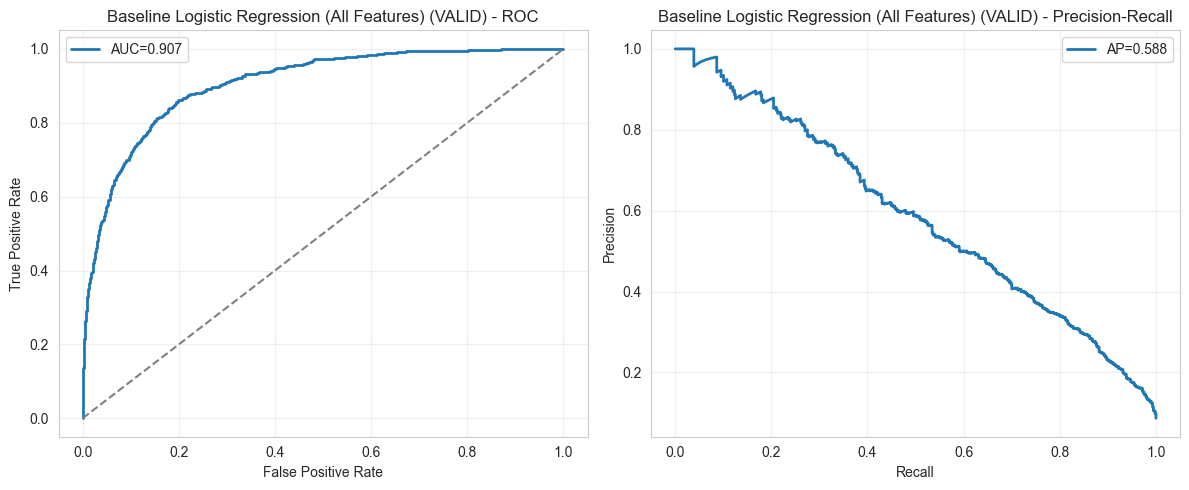

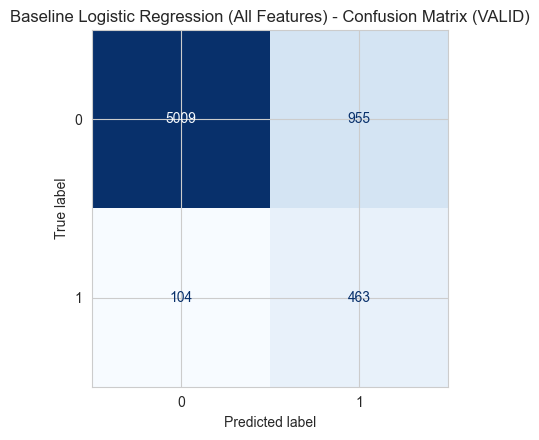

{'Model': 'Logistic Regression (Selected)',
 'VALID_ROC_AUC': 0.9065915185409931,
 'VALID_PR_AUC': 0.5883671274813389}

In [10]:
#Baseline model of Logistic Regression on all features
lr_baseline = LogisticRegression(
    penalty=None,
    solver="lbfgs",
    class_weight="balanced",
    max_iter=2000,
    random_state=RANDOM_STATE
)
_,lr_baseline = fit_and_evaluate(lr_baseline, X_train_imputed, y_train, X_val_imputed, y_val, name="Baseline Logistic Regression (All Features)")

{'Model': 'Logistic Regression (Selected)', 'VALID_ROC_AUC': 0.9065915185409931, 'VALID_PR_AUC': 0.5883671274813389}

/opt/anaconda3/envs/sph6004_project/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
/opt/anaconda3/envs/sph6004_project/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(


Elastic Net best C: 0.0610540229658533
Elastic Net best l1_ratio: 0.5


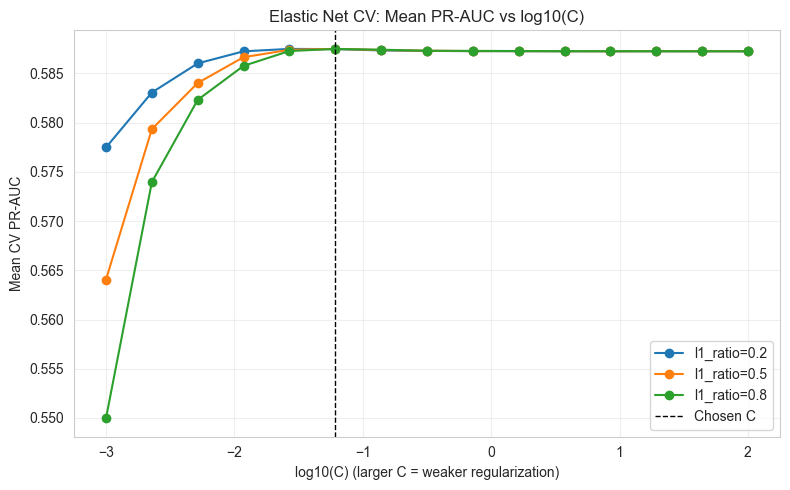

Total features: 62
Selected features: 58


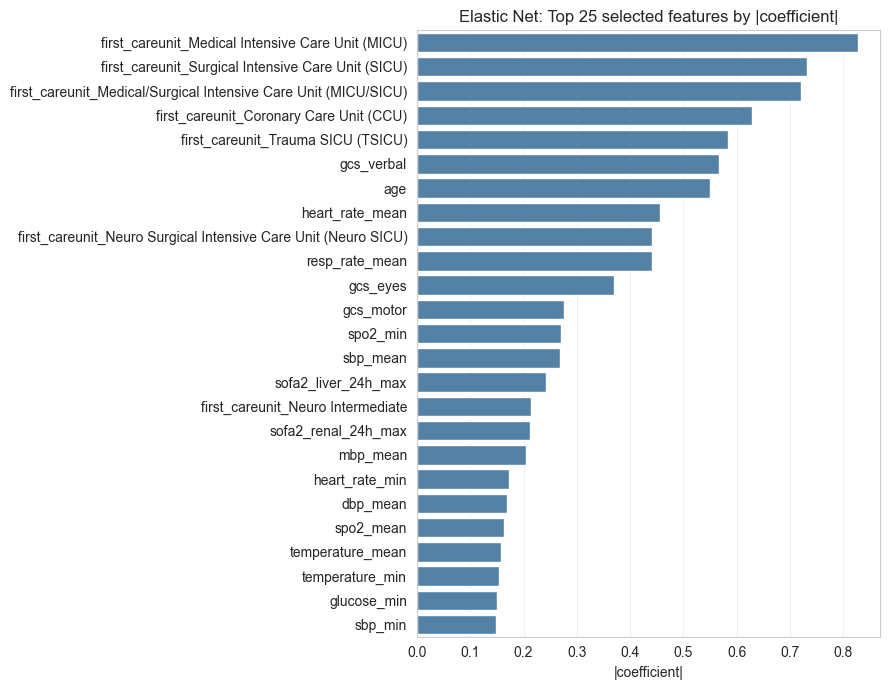

Features that were dropped: {'race_simplified_Black', 'race_simplified_Other', 'insurance_Medicare', 'marital_status_MARRIED'}


In [11]:
#Performing feature selection using Elastic Net LogisticRegressionCV
Cs = np.logspace(-3, 2, 15)

enet_cv = LogisticRegressionCV(
    Cs=Cs,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    penalty="elasticnet",
    solver="saga",
    l1_ratios=[0.2,0.5,0.8],  
    scoring="average_precision",  
    class_weight="balanced",
    max_iter=4000,
    n_jobs=-1,
    refit=True,
    random_state=RANDOM_STATE
)
enet_cv.fit(X_train_imputed, y_train)

best_C = float(enet_cv.C_[0])
best_l1r = float(enet_cv.l1_ratio_[0])
print("Elastic Net best C:", best_C)
print("Elastic Net best l1_ratio:", best_l1r)

# Plot CV PR-AUC vs C for each l1_ratio
scores = enet_cv.scores_[1]               # (n_folds, n_Cs, n_l1_ratios)
mean_scores = scores.mean(axis=0)         # (n_Cs, n_l1_ratios)

plt.figure(figsize=(8, 5))
for j, l1r in enumerate(enet_cv.l1_ratios_):
    plt.plot(np.log10(Cs), mean_scores[:, j], marker="o", label=f"l1_ratio={l1r}")
plt.axvline(np.log10(best_C), color="black", ls="--", lw=1, label="Chosen C")
plt.title("Elastic Net CV: Mean PR-AUC vs log10(C)")
plt.xlabel("log10(C) (larger C = weaker regularization)")
plt.ylabel("Mean CV PR-AUC")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Select non-zero coefficient features
feature_names = np.array(X_train_imputed.columns)
coefs = enet_cv.coef_.ravel()
selected_mask = np.abs(coefs) > 1e-8
selected_features = feature_names[selected_mask]

print("Total features:", len(feature_names))
print("Selected features:", len(selected_features))

# Top coefficients plot
coef_df = pd.DataFrame({"feature": feature_names, "coef": coefs})
coef_df["abs_coef"] = coef_df["coef"].abs()
coef_top = coef_df[coef_df["abs_coef"] > 0].sort_values("abs_coef", ascending=False).head(25)

plt.figure(figsize=(9, 7))
sns.barplot(data=coef_top, y="feature", x="abs_coef", color="steelblue")
plt.title("Elastic Net: Top 25 selected features by |coefficient|")
plt.xlabel("|coefficient|")
plt.ylabel("")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# Reduce datasets
X_train_sel = X_train_imputed[selected_features].copy()
X_val_sel   = X_val_imputed[selected_features].copy()
X_test_sel  = X_test_imputed[selected_features].copy()

print("Features that were dropped:", set(feature_names) - set(selected_features))


/opt/anaconda3/envs/sph6004_project/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Logistic Regression (Selected)  (evaluated on VALID)
{'Model': 'Logistic Regression (Selected)', 'VALID_ROC_AUC': 0.9065915185409931, 'VALID_PR_AUC': 0.5883671274813389}

Classification report (VALID):
              precision    recall  f1-score   support

           0     0.9797    0.8395    0.9042      5964
           1     0.3261    0.8166    0.4660       567

    accuracy                         0.8375      6531
   macro avg     0.6529    0.8281    0.6851      6531
weighted avg     0.9229    0.8375    0.8662      6531



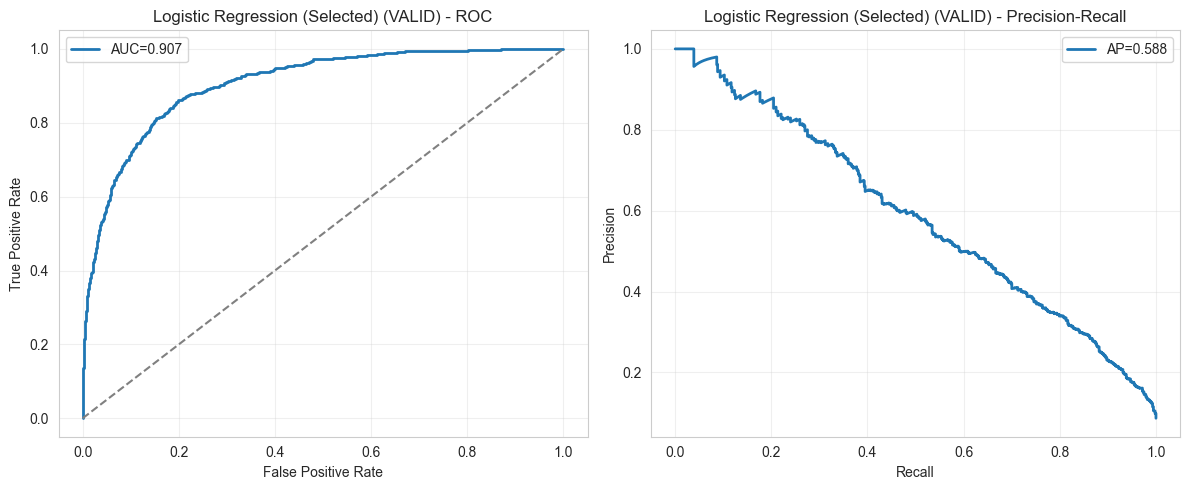

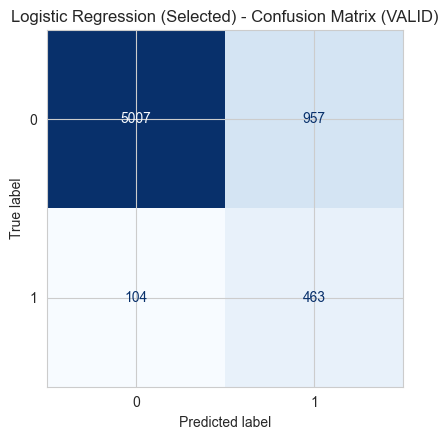

SVM RBF (Selected)  (evaluated on VALID)
{'Model': 'SVM RBF (Selected)', 'VALID_ROC_AUC': 0.9116979951431103, 'VALID_PR_AUC': 0.5314692203888007}

Classification report (VALID):
              precision    recall  f1-score   support

           0     0.9769    0.8851    0.9287      5964
           1     0.3922    0.7795    0.5218       567

    accuracy                         0.8760      6531
   macro avg     0.6845    0.8323    0.7253      6531
weighted avg     0.9261    0.8760    0.8934      6531



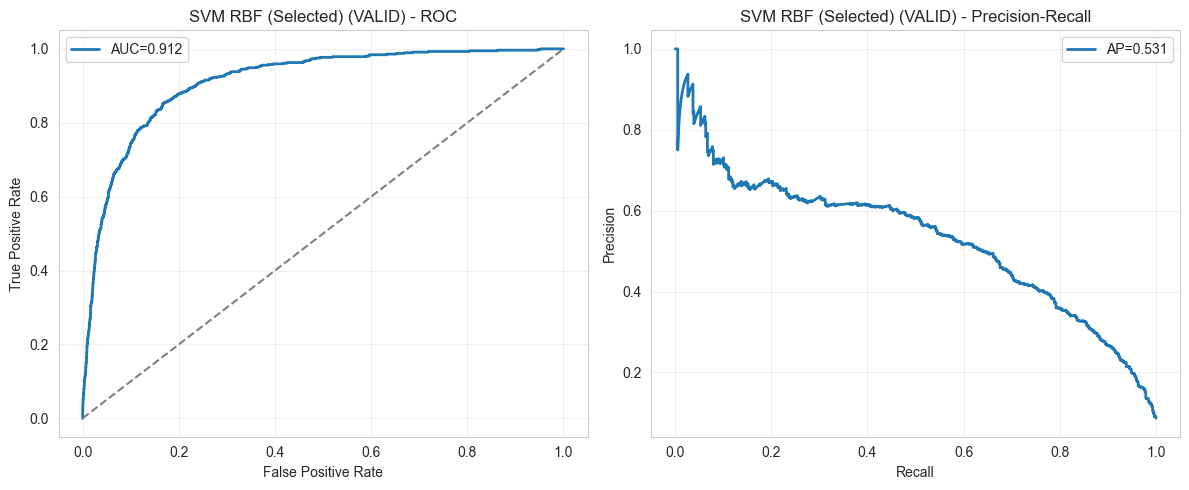

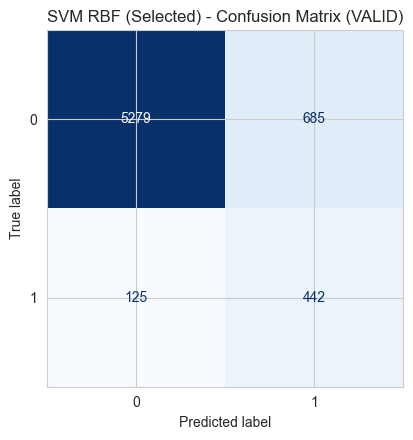

Random Forest (Selected)  (evaluated on VALID)
{'Model': 'Random Forest (Selected)', 'VALID_ROC_AUC': 0.9127701245686937, 'VALID_PR_AUC': 0.6286979397246744}

Classification report (VALID):
              precision    recall  f1-score   support

           0     0.9404    0.9916    0.9653      5964
           1     0.7934    0.3386    0.4747       567

    accuracy                         0.9349      6531
   macro avg     0.8669    0.6651    0.7200      6531
weighted avg     0.9276    0.9349    0.9227      6531



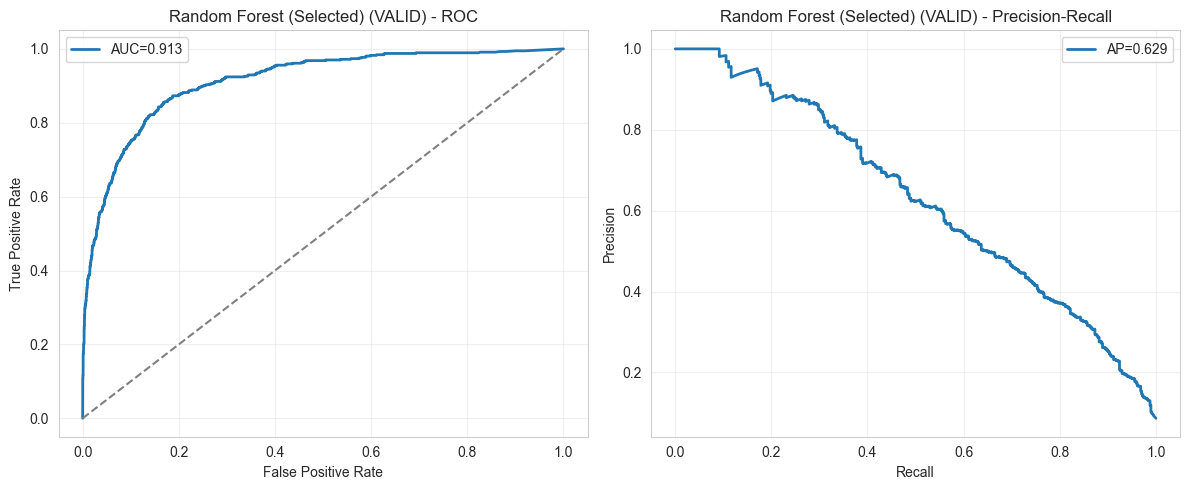

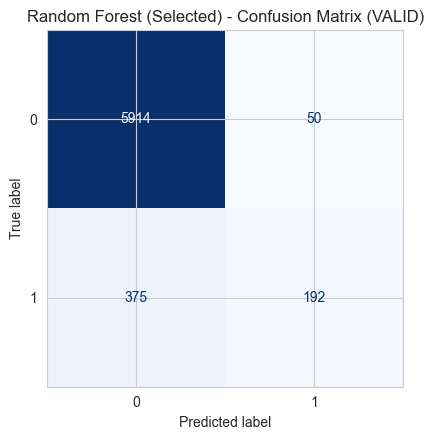

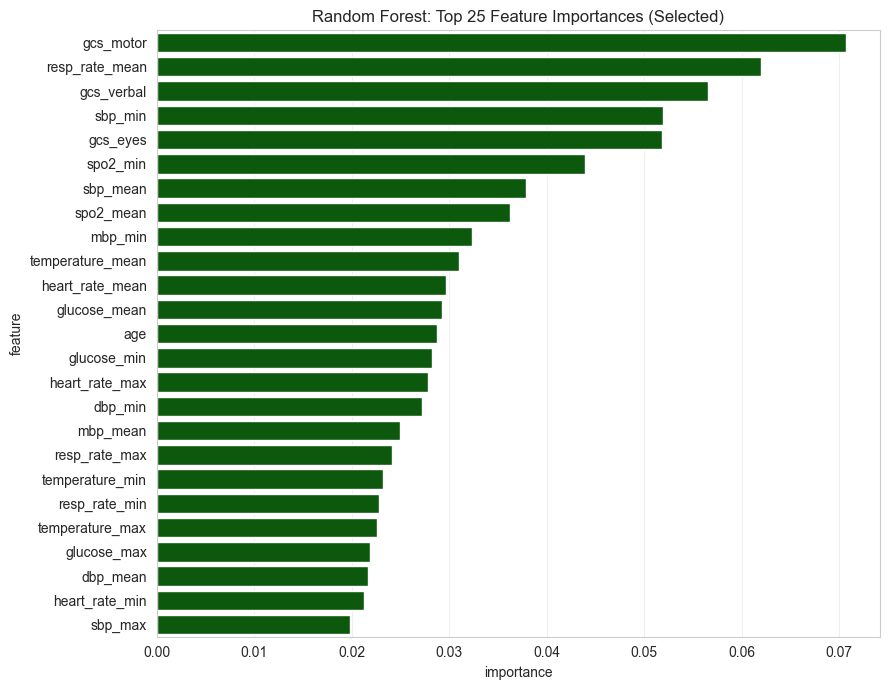


AdaBoost minimal tuning results:
    learning_rate   ROC_AUC    PR_AUC
5           1.00  0.903878  0.601955
3           0.20  0.888978  0.567204
4           0.50  0.890739  0.566893
2           0.10  0.881731  0.551419
1           0.05  0.872945  0.532209
0           0.01  0.845186  0.445713


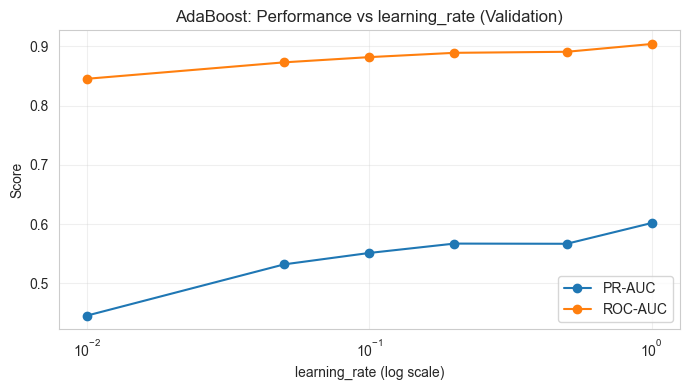

AdaBoost (lr=1.0)  (evaluated on VALID)
{'Model': 'AdaBoost (lr=1.0)', 'VALID_ROC_AUC': 0.9038782962324209, 'VALID_PR_AUC': 0.6019552849860257}

Classification report (VALID):
              precision    recall  f1-score   support

           0     0.9442    0.9852    0.9643      5964
           1     0.7143    0.3880    0.5029       567

    accuracy                         0.9334      6531
   macro avg     0.8293    0.6866    0.7336      6531
weighted avg     0.9243    0.9334    0.9242      6531



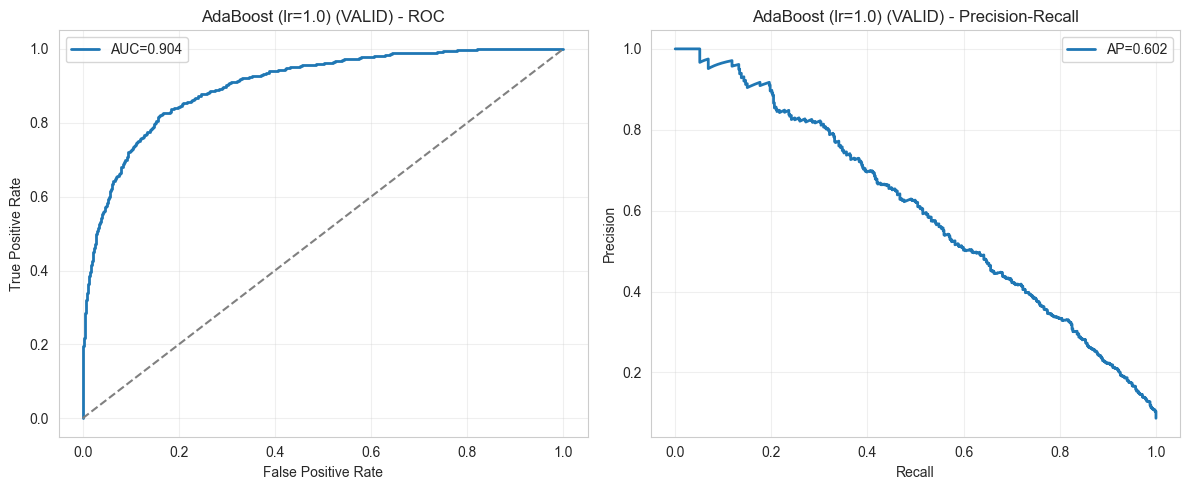

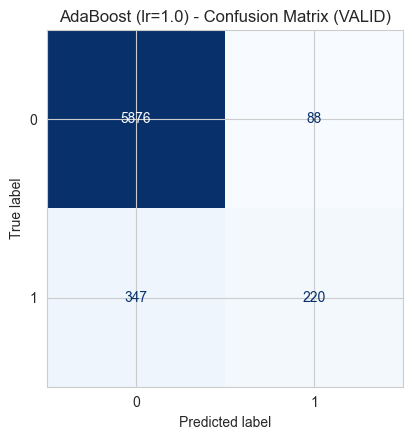


GradientBoost minimal tuning results:
    learning_rate   ROC_AUC    PR_AUC
2           0.10  0.918793  0.651046
1           0.05  0.916012  0.644798
3           0.20  0.920391  0.640693
0           0.01  0.893146  0.591626
4           0.50  0.906309  0.588385
5           1.00  0.843985  0.523788


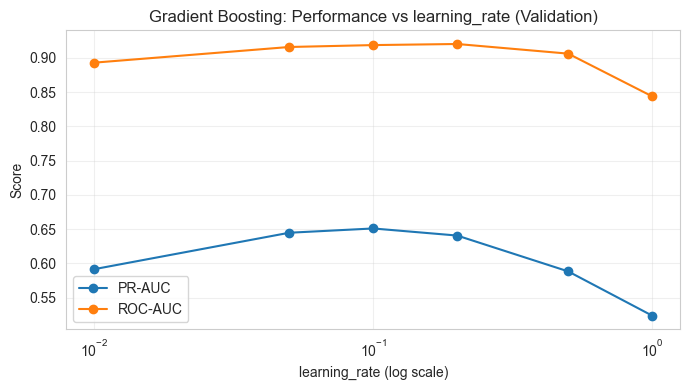

GradientBoost (lr=0.1)  (evaluated on VALID)
{'Model': 'GradientBoost (lr=0.1)', 'VALID_ROC_AUC': 0.9187934780937239, 'VALID_PR_AUC': 0.6510460788384039}

Classification report (VALID):
              precision    recall  f1-score   support

           0     0.9500    0.9869    0.9681      5964
           1     0.7672    0.4533    0.5698       567

    accuracy                         0.9406      6531
   macro avg     0.8586    0.7201    0.7690      6531
weighted avg     0.9341    0.9406    0.9335      6531



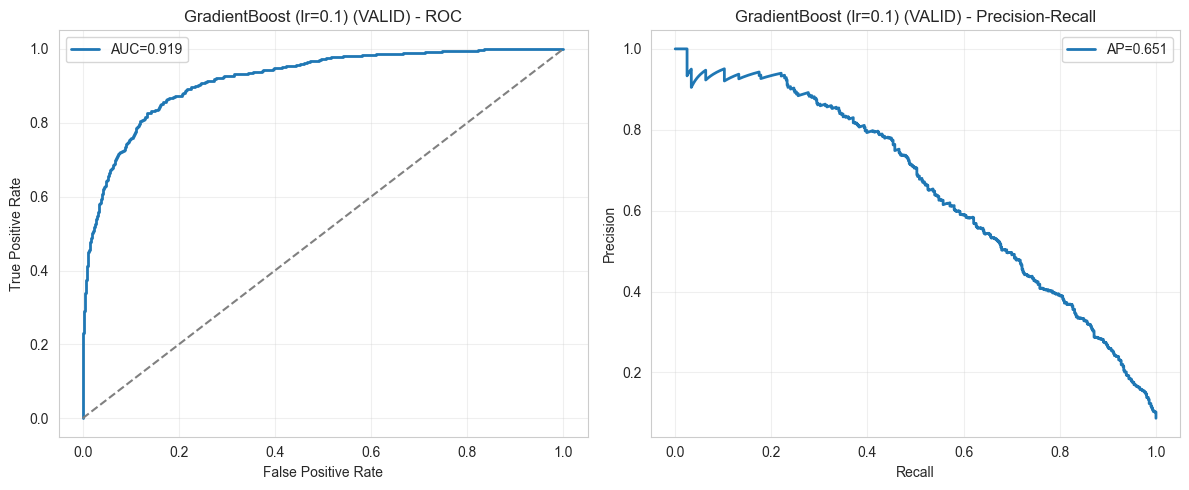

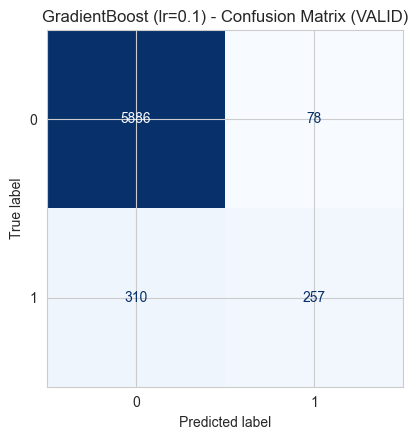

In [12]:
#Training and evaluating models on validation set with selected features
results = []

#Logistic Regression (L2) on selected features
lr = LogisticRegression(
    penalty="l2", solver="liblinear",
    class_weight="balanced",
    max_iter=2000,
    random_state=RANDOM_STATE
)
res, lr = fit_and_evaluate(lr, X_train_sel, y_train, X_val_sel, y_val, name="Logistic Regression (Selected)")
results.append(res)

#SVM (RBF) on selected features
svm = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    class_weight="balanced",
    probability=True,
    random_state=RANDOM_STATE
)
res, svm = fit_and_evaluate(svm, X_train_sel, y_train, X_val_sel, y_val, name="SVM RBF (Selected)")
results.append(res)

#Random Forest on selected features
rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=2,
    n_jobs=-1,
    class_weight="balanced",
    random_state=RANDOM_STATE
)
res, rf = fit_and_evaluate(rf, X_train_sel, y_train, X_val_sel, y_val, name="Random Forest (Selected)")
results.append(res)

#RF feature importance plot (top 25)
imp_rf = pd.DataFrame({
    "feature": selected_features,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False).head(25)

plt.figure(figsize=(9, 7))
sns.barplot(data=imp_rf, y="feature", x="importance", color="darkgreen")
plt.title("Random Forest: Top 25 Feature Importances (Selected)")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

#AdaBoost learning_rate minimal tuning
learning_rates = [0.01, 0.05, 0.1, 0.2, 0.5, 1.0]
ada_rows = []

for lr_ in learning_rates:
    ada = AdaBoostClassifier(
        n_estimators=300,
        learning_rate=lr_,
        random_state=RANDOM_STATE
    )
    ada.fit(X_train_sel, y_train)
    proba_test = ada.predict_proba(X_val_sel)[:, 1]
    ada_rows.append({
        "learning_rate": lr_,
        "ROC_AUC": roc_auc_score(y_val, proba_test),
        "PR_AUC": average_precision_score(y_val, proba_test)
    })

ada_df = pd.DataFrame(ada_rows).sort_values("PR_AUC", ascending=False)
print("\nAdaBoost minimal tuning results:\n", ada_df)

plt.figure(figsize=(7, 4))
plt.plot(ada_df.sort_values("learning_rate")["learning_rate"], ada_df.sort_values("learning_rate")["PR_AUC"], marker="o", label="PR-AUC")
plt.plot(ada_df.sort_values("learning_rate")["learning_rate"], ada_df.sort_values("learning_rate")["ROC_AUC"], marker="o", label="ROC-AUC")
plt.xscale("log")
plt.title("AdaBoost: Performance vs learning_rate (Validation)")
plt.xlabel("learning_rate (log scale)")
plt.ylabel("Score")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

best_lr_ada = float(ada_df.iloc[0]["learning_rate"])
ada_best = AdaBoostClassifier(
    n_estimators=300,
    learning_rate=best_lr_ada,
    random_state=RANDOM_STATE
)
res, ada_best = fit_and_evaluate(ada_best, X_train_sel, y_train, X_val_sel, y_val, name=f"AdaBoost (lr={best_lr_ada})")
results.append(res)

#Gradient Boosting learning_rate minimal tuning
gb_rows = []
for lr_ in learning_rates:
    gb = GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=lr_,
        random_state=RANDOM_STATE
    )
    gb.fit(X_train_sel, y_train)
    proba_test = gb.predict_proba(X_val_sel)[:, 1]
    gb_rows.append({
        "learning_rate": lr_,
        "ROC_AUC": roc_auc_score(y_val, proba_test),
        "PR_AUC": average_precision_score(y_val, proba_test)
    })

gb_df = pd.DataFrame(gb_rows).sort_values("PR_AUC", ascending=False)
print("\nGradientBoost minimal tuning results:\n", gb_df)

plt.figure(figsize=(7, 4))
plt.plot(gb_df.sort_values("learning_rate")["learning_rate"], gb_df.sort_values("learning_rate")["PR_AUC"], marker="o", label="PR-AUC")
plt.plot(gb_df.sort_values("learning_rate")["learning_rate"], gb_df.sort_values("learning_rate")["ROC_AUC"], marker="o", label="ROC-AUC")
plt.xscale("log")
plt.title("Gradient Boosting: Performance vs learning_rate (Validation)")
plt.xlabel("learning_rate (log scale)")
plt.ylabel("Score")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

best_lr_gb = float(gb_df.iloc[0]["learning_rate"])
gb_best = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=best_lr_gb,
    random_state=RANDOM_STATE
)
res, gb_best = fit_and_evaluate(gb_best, X_train_sel, y_train, X_val_sel, y_val, name=f"GradientBoost (lr={best_lr_gb})")
results.append(res) 



Baseline Logistic Regression (All Features)  (FINAL evaluation on TEST)
{'Model': 'Baseline Logistic Regression (All Features)', 'TEST_ROC_AUC': 0.9050165583945594, 'TEST_PR_AUC': 0.5962396285188986}

Classification report (TEST):
              precision    recall  f1-score   support

           0     0.9766    0.8397    0.9030      5970
           1     0.3184    0.7884    0.4536       567

    accuracy                         0.8352      6537
   macro avg     0.6475    0.8140    0.6783      6537
weighted avg     0.9195    0.8352    0.8640      6537



/opt/anaconda3/envs/sph6004_project/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


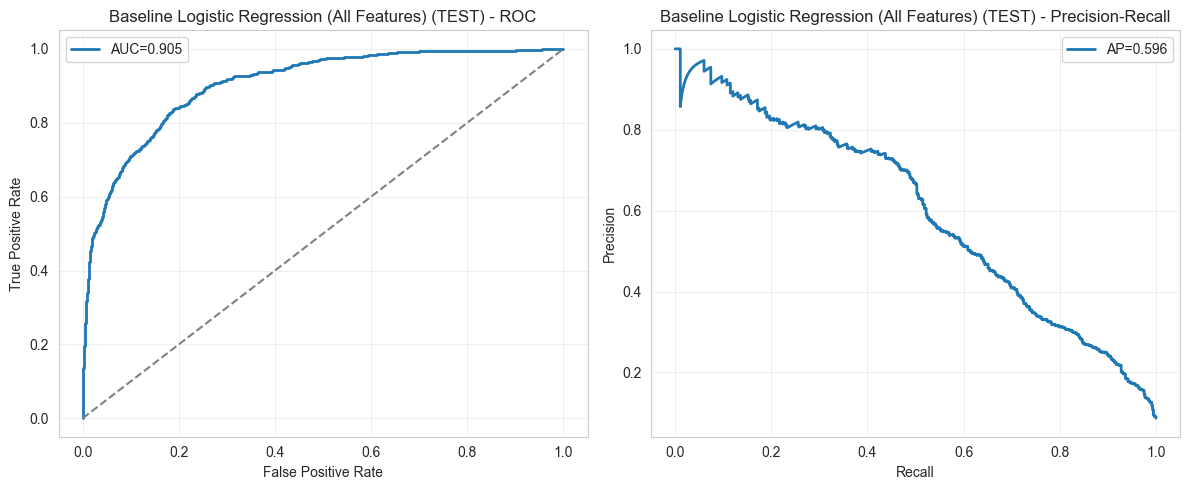

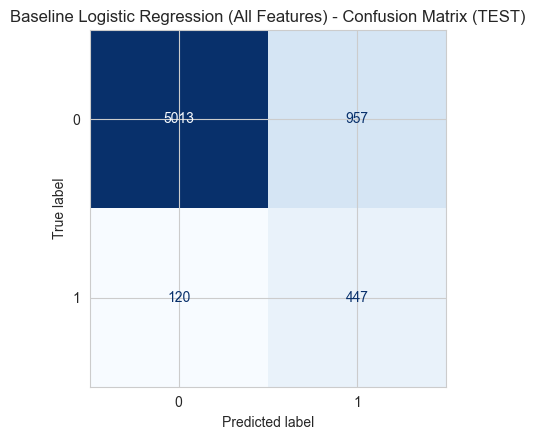

/opt/anaconda3/envs/sph6004_project/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(



Logistic Regression (Selected)  (FINAL evaluation on TEST)
{'Model': 'Logistic Regression (Selected)', 'TEST_ROC_AUC': 0.9050357608146553, 'TEST_PR_AUC': 0.5959723946960159}

Classification report (TEST):
              precision    recall  f1-score   support

           0     0.9764    0.8397    0.9029      5970
           1     0.3179    0.7866    0.4528       567

    accuracy                         0.8351      6537
   macro avg     0.6472    0.8131    0.6779      6537
weighted avg     0.9193    0.8351    0.8639      6537



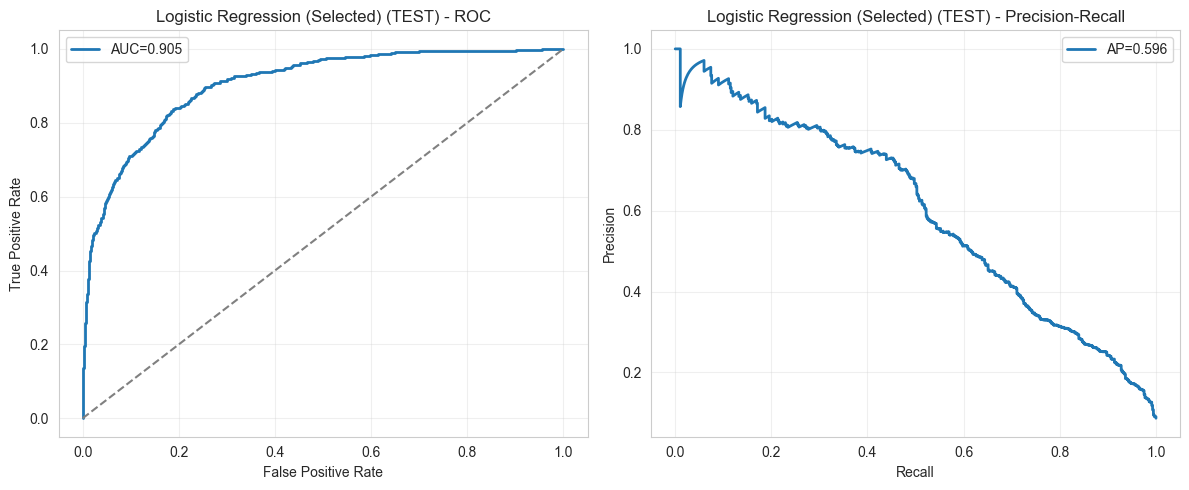

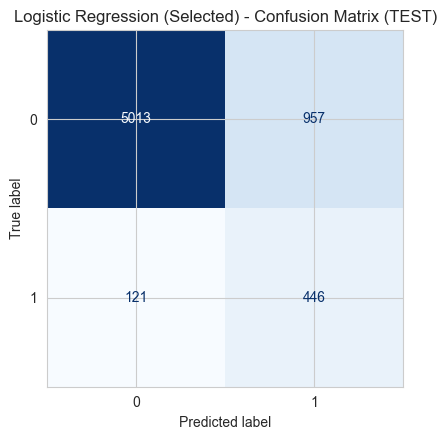


SVM RBF (Selected)  (FINAL evaluation on TEST)
{'Model': 'SVM RBF (Selected)', 'TEST_ROC_AUC': 0.9067882032147806, 'TEST_PR_AUC': 0.5305725797512851}

Classification report (TEST):
              precision    recall  f1-score   support

           0     0.9752    0.8879    0.9295      5970
           1     0.3924    0.7619    0.5180       567

    accuracy                         0.8770      6537
   macro avg     0.6838    0.8249    0.7237      6537
weighted avg     0.9246    0.8770    0.8938      6537



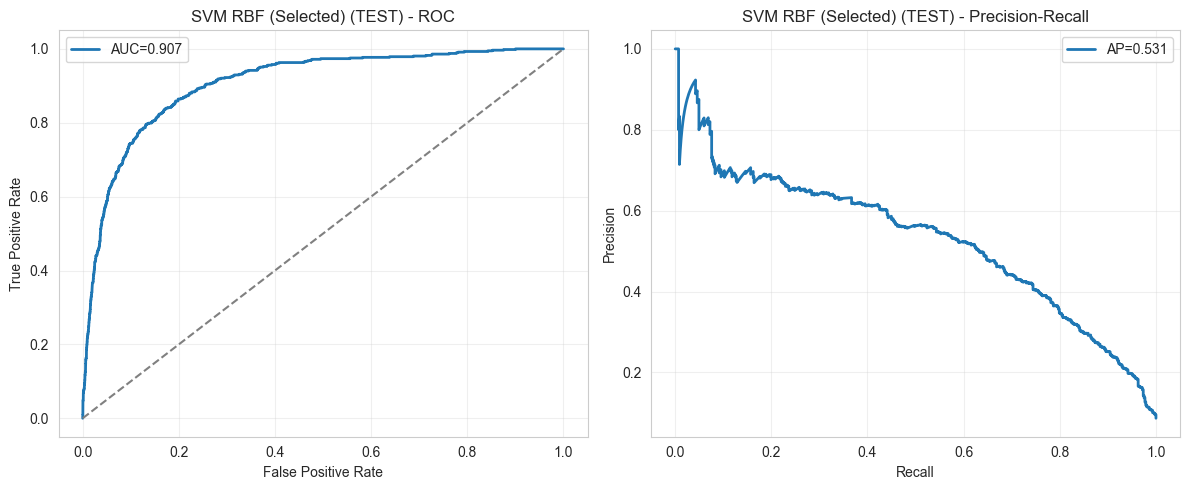

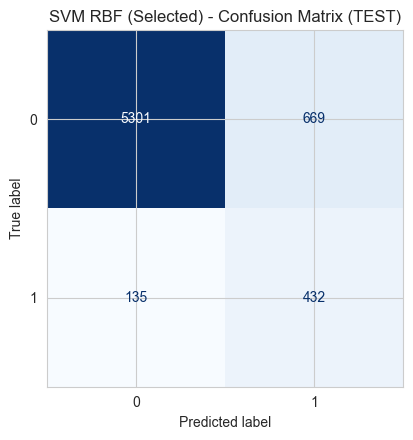


Random Forest (Selected)  (FINAL evaluation on TEST)
{'Model': 'Random Forest (Selected)', 'TEST_ROC_AUC': 0.9174567723981459, 'TEST_PR_AUC': 0.6226430849135569}

Classification report (TEST):
              precision    recall  f1-score   support

           0     0.9390    0.9920    0.9647      5970
           1     0.7913    0.3210    0.4567       567

    accuracy                         0.9338      6537
   macro avg     0.8651    0.6565    0.7107      6537
weighted avg     0.9261    0.9338    0.9207      6537



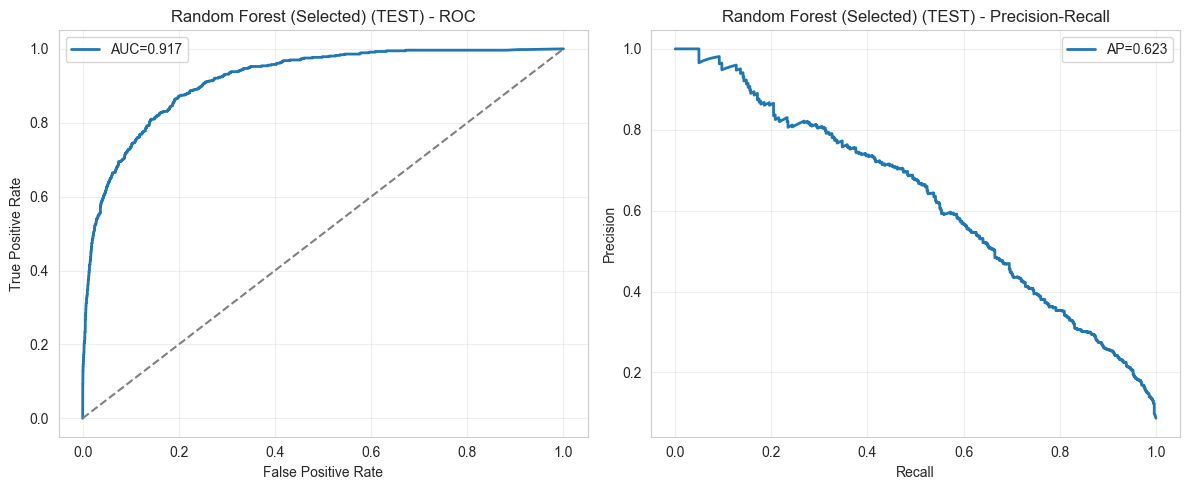

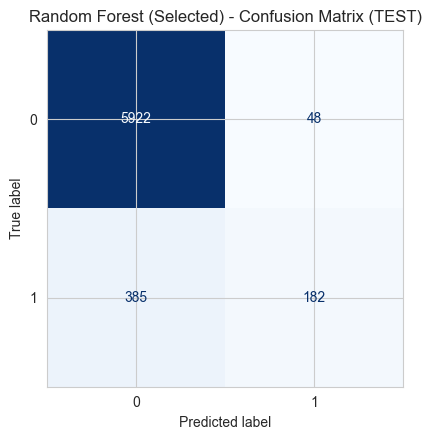


AdaBoost (lr=1.0)  (FINAL evaluation on TEST)
{'Model': 'AdaBoost (lr=1.0)', 'TEST_ROC_AUC': 0.9073760926915588, 'TEST_PR_AUC': 0.5954573004409627}

Classification report (TEST):
              precision    recall  f1-score   support

           0     0.9411    0.9878    0.9639      5970
           1     0.7306    0.3492    0.4726       567

    accuracy                         0.9324      6537
   macro avg     0.8359    0.6685    0.7182      6537
weighted avg     0.9229    0.9324    0.9213      6537



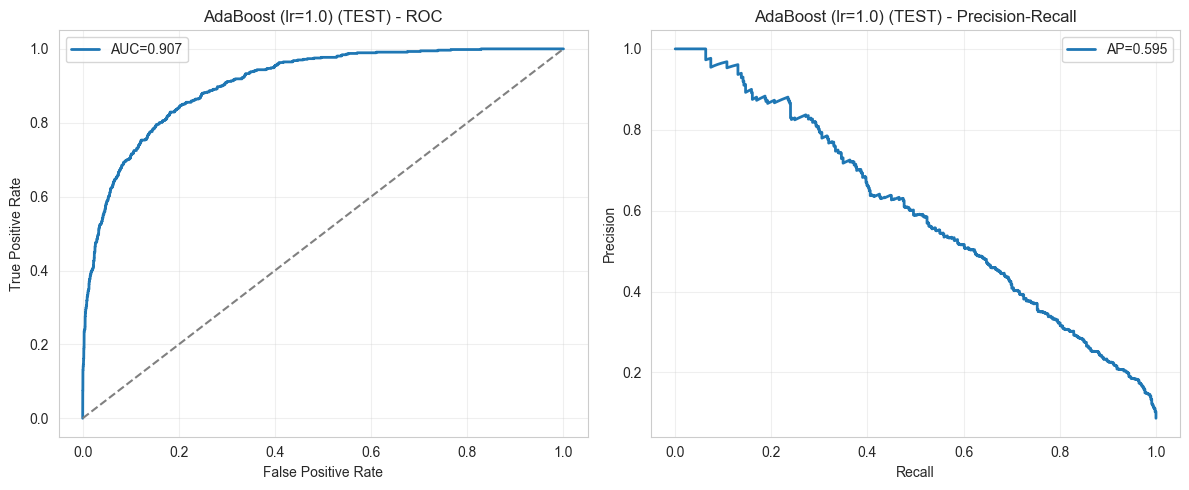

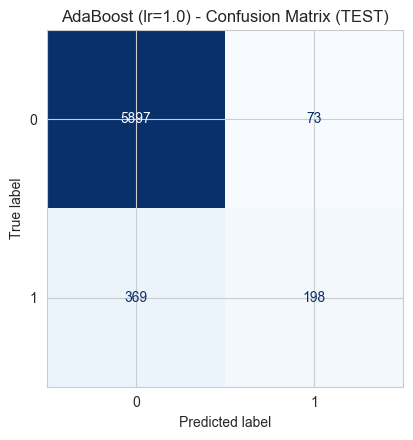


GradientBoost (lr=0.1)  (FINAL evaluation on TEST)
{'Model': 'GradientBoost (lr=0.1)', 'TEST_ROC_AUC': 0.9234739245906192, 'TEST_PR_AUC': 0.6483211352947411}

Classification report (TEST):
              precision    recall  f1-score   support

           0     0.9475    0.9856    0.9662      5970
           1     0.7370    0.4250    0.5391       567

    accuracy                         0.9370      6537
   macro avg     0.8423    0.7053    0.7527      6537
weighted avg     0.9292    0.9370    0.9291      6537



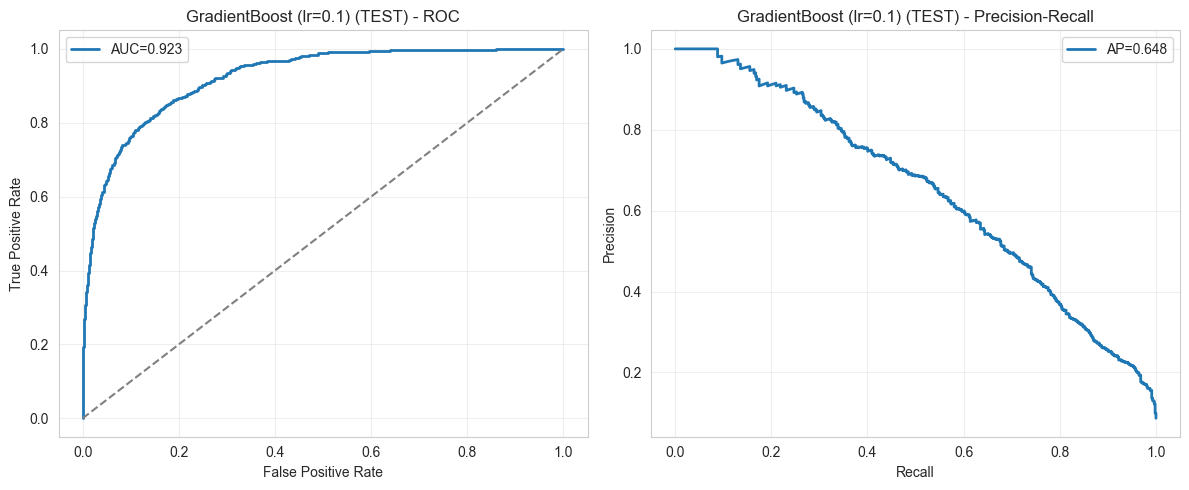

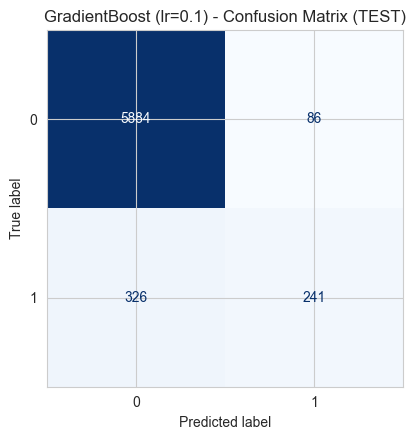


FINAL TEST RESULTS (sorted by TEST_PR_AUC):
                                          Model  TEST_ROC_AUC  TEST_PR_AUC
5                       GradientBoost (lr=0.1)      0.923474     0.648321
3                     Random Forest (Selected)      0.917457     0.622643
0  Baseline Logistic Regression (All Features)      0.905017     0.596240
1               Logistic Regression (Selected)      0.905036     0.595972
4                            AdaBoost (lr=1.0)      0.907376     0.595457
2                           SVM RBF (Selected)      0.906788     0.530573


In [13]:
#Training the final models on TRAIN+VAL and evaluating on TEST

X_trainval_sel = pd.concat([X_train_sel, X_val_sel], axis=0)
y_trainval = pd.concat([y_train, y_val], axis=0)

final_models = [
    ("Baseline Logistic Regression (All Features)",
     LogisticRegression(penalty=None, solver="lbfgs", class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE),
     X_train_imputed, pd.concat([X_train_imputed, X_val_imputed], axis=0), X_test_imputed),

    ("Logistic Regression (Selected)",
     LogisticRegression(penalty="l2", solver="liblinear", class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE),
     X_train_sel, X_trainval_sel, X_test_sel),

    ("SVM RBF (Selected)",
     SVC(kernel="rbf", C=1.0, gamma="scale", class_weight="balanced", probability=True, random_state=RANDOM_STATE),
     X_train_sel, X_trainval_sel, X_test_sel),

    ("Random Forest (Selected)",
     RandomForestClassifier(n_estimators=400, max_depth=None, min_samples_leaf=2, n_jobs=-1,
                            class_weight="balanced", random_state=RANDOM_STATE),
     X_train_sel, X_trainval_sel, X_test_sel),

    (f"AdaBoost (lr={best_lr_ada})",
     AdaBoostClassifier(n_estimators=300, learning_rate=best_lr_ada, random_state=RANDOM_STATE),
     X_train_sel, X_trainval_sel, X_test_sel),

    (f"GradientBoost (lr={best_lr_gb})",
     GradientBoostingClassifier(n_estimators=300, learning_rate=best_lr_gb, random_state=RANDOM_STATE),
     X_train_sel, X_trainval_sel, X_test_sel),
]

test_results = []
trained_for_plots = []

for name, mdl, _Xtrain_for_shape, Xtrval, Xte in final_models:
    # Fit on TRAIN+VAL
    mdl.fit(Xtrval, y_trainval)

    proba_test = _get_proba_or_score(mdl, Xte)
    pred_test = mdl.predict(Xte)

    row = {
        "Model": name,
        "TEST_ROC_AUC": roc_auc_score(y_test, proba_test),
        "TEST_PR_AUC": average_precision_score(y_test, proba_test),
    }
    test_results.append(row)
    trained_for_plots.append((name, mdl, Xte))

    print("\n" + "=" * 70)
    print(f"{name}  (FINAL evaluation on TEST)")
    print("=" * 70)
    print(row)
    print("\nClassification report (TEST):")
    print(classification_report(y_test, pred_test, digits=4))

    plot_roc_pr(y_test, proba_test, title_prefix=f"{name} (TEST)")
    plot_confusion(y_test, pred_test, title=f"{name} - Confusion Matrix (TEST)")

test_df = pd.DataFrame(test_results).sort_values("TEST_PR_AUC", ascending=False)
print("\nFINAL TEST RESULTS (sorted by TEST_PR_AUC):\n", test_df)

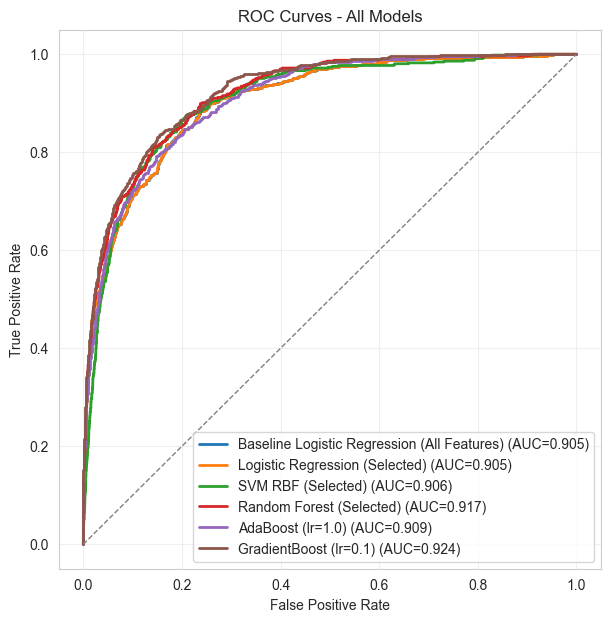

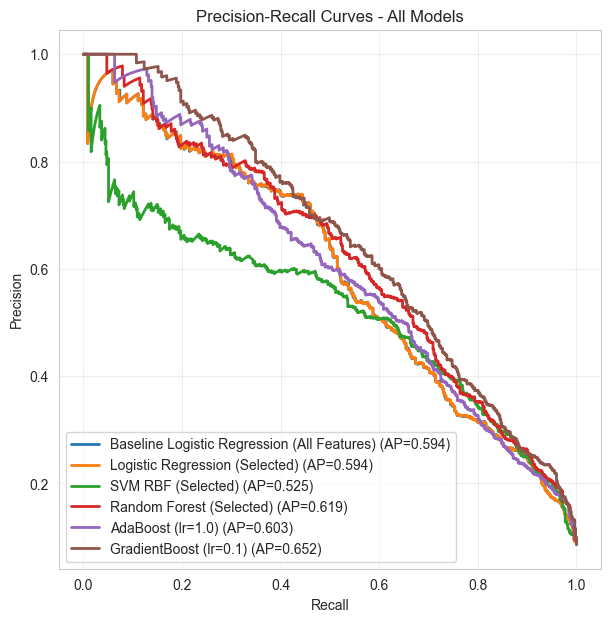

In [14]:
#Aggregate ROC and PR curves using trained model variables
models_to_plot = [
    ("Baseline Logistic Regression (All Features)", lr_baseline, X_test_imputed),
    ("Logistic Regression (Selected)", lr, X_test_sel),
    ("SVM RBF (Selected)", svm, X_test_sel),
    ("Random Forest (Selected)", rf, X_test_sel),
    (f"AdaBoost (lr={best_lr_ada})", ada_best, X_test_sel),
    (f"GradientBoost (lr={best_lr_gb})", gb_best, X_test_sel),
]

#ROC comparison
plt.figure(figsize=(7,7))
for name, mdl, Xtest in models_to_plot:
    if hasattr(mdl, "predict_proba"):
        proba = mdl.predict_proba(Xtest)[:,1]
    else:
        scores = mdl.decision_function(Xtest)
        proba = (scores - scores.min()) / (scores.max()-scores.min()+1e-12)
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC={auc_val:.3f})")

plt.plot([0,1],[0,1], color='gray', linestyle='--', lw=1)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models')
plt.legend(loc='lower right'); plt.grid(alpha=0.3)
plt.show()

#PR comparison
plt.figure(figsize=(7,7))
for name, mdl, Xtest in models_to_plot:
    if hasattr(mdl, "predict_proba"):
        proba = mdl.predict_proba(Xtest)[:,1]
    else:
        scores = mdl.decision_function(Xtest)
        proba = (scores - scores.min()) / (scores.max()-scores.min()+1e-12)
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap_val = average_precision_score(y_test, proba)
    plt.plot(rec, prec, lw=2, label=f"{name} (AP={ap_val:.3f})")

plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision-Recall Curves - All Models')
plt.legend(loc='lower left'); plt.grid(alpha=0.3)
plt.show()

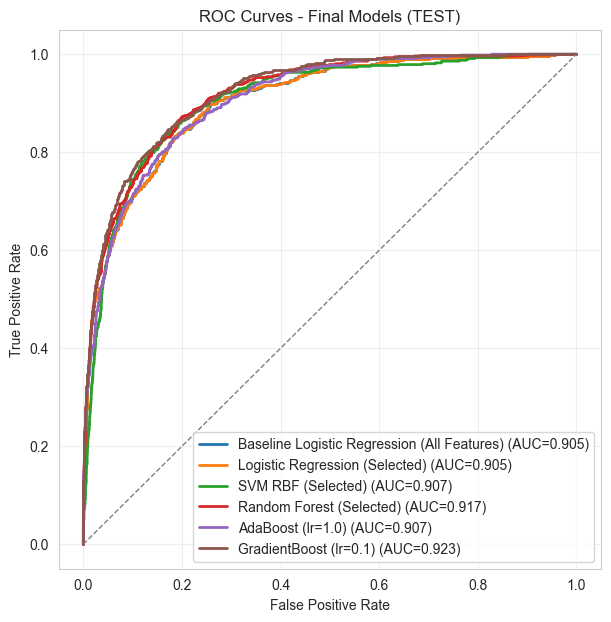

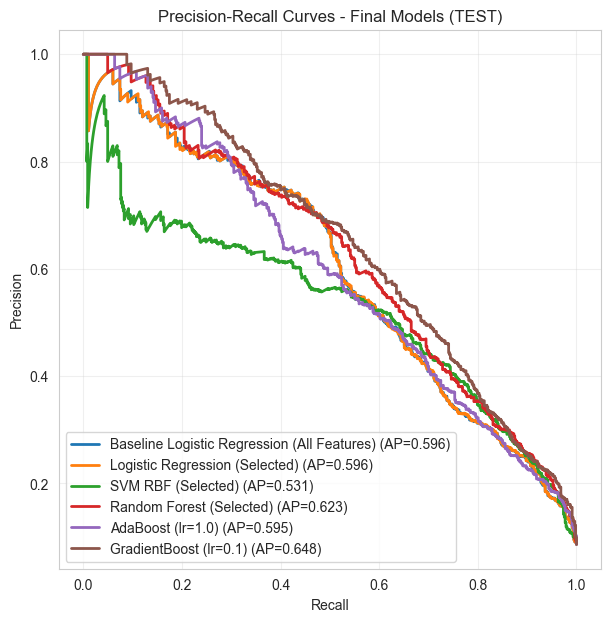

In [15]:
#Aggregate ROC/PR curves on TEST (final comparison)

#ROC comparison
plt.figure(figsize=(7, 7))
for name, mdl, Xte in trained_for_plots:
    proba = _get_proba_or_score(mdl, Xte)
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC={auc_val:.3f})")

plt.plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Final Models (TEST)")
plt.legend(loc="lower right"); plt.grid(alpha=0.3)
plt.show()

#PR comparison
plt.figure(figsize=(7, 7))
for name, mdl, Xte in trained_for_plots:
    proba = _get_proba_or_score(mdl, Xte)
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap_val = average_precision_score(y_test, proba)
    plt.plot(rec, prec, lw=2, label=f"{name} (AP={ap_val:.3f})")

plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision-Recall Curves - Final Models (TEST)")
plt.legend(loc="lower left"); plt.grid(alpha=0.3)
plt.show()